# Looking at Bell Field

This is code for looking at the data we've collected across all of Bell Field. It loads in all of the continuous and manual data for each piezometer and each creek monitoring station. It explains the code less thoroughly than the script meant for one monitoring station.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

The code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells. After running it once, the package is installed in your environment, and you should comment out the cell to keep your cache clear.

In [26]:
# pip install hampel

In [27]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [28]:
import os # Allows python to communicate directly with the computer's operating system

# Reading in all the Hobo Data

In [69]:
# P1
P1hobodf = pd.read_csv('P1_current.csv')
P1hobodf = P1hobodf.dropna()

P1hobodf['Date-Time'] = pd.to_datetime(P1hobodf['Date-Time']) 
P1hobodf.index = pd.DatetimeIndex(P1hobodf['Date-Time']) 

In [70]:
# P2
P2hobodf = pd.read_csv('P2_current.csv')
P2hobodf = P2hobodf.dropna()

P2hobodf['Date-Time'] = pd.to_datetime(P2hobodf['Date-Time']) 
P2hobodf.index = pd.DatetimeIndex(P2hobodf['Date-Time']) 

In [71]:
# P3
P3hobodf = pd.read_csv('P3_current.csv')
P3hobodf = P3hobodf.dropna()

P3hobodf['Date-Time'] = pd.to_datetime(P3hobodf['Date-Time']) 
P3hobodf.index = pd.DatetimeIndex(P3hobodf['Date-Time']) 

In [72]:
# P4
P4hobodf = pd.read_csv('P4_current.csv')
P4hobodf = P4hobodf.dropna()

P4hobodf['Date-Time'] = pd.to_datetime(P4hobodf['Date-Time']) 
P4hobodf.index = pd.DatetimeIndex(P4hobodf['Date-Time']) 

In [73]:
# P5
P5hobodf = pd.read_csv('P5_current.csv')
P5hobodf = P5hobodf.dropna()

P5hobodf['Date-Time'] = pd.to_datetime(P5hobodf['Date-Time']) 
P5hobodf.index = pd.DatetimeIndex(P5hobodf['Date-Time']) 

In [74]:
# C1
C1hobodf = pd.read_csv('P1_creek_current.csv')
C1hobodf = C1hobodf.dropna()

C1hobodf['Date-Time'] = pd.to_datetime(C1hobodf['Date-Time']) 
C1hobodf.index = pd.DatetimeIndex(C1hobodf['Date-Time']) 

In [75]:
# Downstream (near P1)
downst = pd.read_csv('Dwnstrm_current.csv')
downst = downst.dropna()

downst['Date-Time'] = pd.to_datetime(downst['Date-Time']) 
downst.index = pd.DatetimeIndex(downst['Date-Time']) 

In [76]:
# C2
C2hobodf = pd.read_csv('P2_creek_current.csv')
C2hobodf = C2hobodf.dropna()

C2hobodf['Date-Time'] = pd.to_datetime(C2hobodf['Date-Time']) 
C2hobodf.index = pd.DatetimeIndex(C2hobodf['Date-Time']) 

In [77]:
# Midstream (near P3)
midst = pd.read_csv('Mdstrm_current.csv')
midst = midst.dropna()

midst['Date-Time'] = pd.to_datetime(midst['Date-Time']) 
midst.index = pd.DatetimeIndex(midst['Date-Time']) 

In [78]:
# Spring (just upstream of P3)
spring = pd.read_csv('Spring_current.csv')
spring = midst.dropna()

spring['Date-Time'] = pd.to_datetime(spring['Date-Time']) 
spring.index = pd.DatetimeIndex(spring['Date-Time']) 

In [79]:
# C4
C4hobodf = pd.read_csv('P4_creek_current.csv')
C4hobodf = C4hobodf.dropna()

C4hobodf['Date-Time'] = pd.to_datetime(C4hobodf['Date-Time']) 
C4hobodf.index = pd.DatetimeIndex(C4hobodf['Date-Time']) 

In [80]:
# C5
C5hobodf = pd.read_csv('P5_creek_cond_current.csv')
C5hobodf = C5hobodf.dropna()

C5hobodf['Date-Time'] = pd.to_datetime(C5hobodf['Date-Time']) 
C5hobodf.index = pd.DatetimeIndex(C5hobodf['Date-Time']) 

# Filtering the data

A hampel filter uses a running average to compute outliers in time-dependent data. Instead of dropping outliers, it replaces them with the local median. Visit https://www.mathworks.com/help/signal/ref/hampel.html for more information.

In [81]:
# P1
P1filtered = hampel(P1hobodf['Temperature'], window_size=6, n_sigma=1.5)
P1filtered = pd.DataFrame(P1filtered.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf['FilteredTemp'] = P1filtered
P1filteredSPC = hampel(P1hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P1filteredSPC = pd.DataFrame(P1filteredSPC.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf['FilteredSPC'] = P1filteredSPC
P1hobodf = P1hobodf.iloc[1:-1]

In [82]:
# P2
P2filtered = hampel(P2hobodf['Temperature'], window_size=6, n_sigma=1.5)
P2filtered = pd.DataFrame(P2filtered.filtered_data.to_numpy(), index=P2hobodf.index)
P2hobodf['FilteredTemp'] = P2filtered
P2filteredSPC = hampel(P2hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P2filteredSPC = pd.DataFrame(P2filteredSPC.filtered_data.to_numpy(), index=P2hobodf.index)
P2hobodf['FilteredSPC'] = P2filteredSPC
P2hobodf = P2hobodf.iloc[1:-1]

In [83]:
# P3
P3filtered = hampel(P3hobodf['Temperature'], window_size=6, n_sigma=1.5)
P3filtered = pd.DataFrame(P3filtered.filtered_data.to_numpy(), index=P3hobodf.index)
P3hobodf['FilteredTemp'] = P3filtered
P3filteredSPC = hampel(P3hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P3filteredSPC = pd.DataFrame(P3filteredSPC.filtered_data.to_numpy(), index=P3hobodf.index)
P3hobodf['FilteredSPC'] = P3filteredSPC
P3hobodf = P3hobodf.iloc[1:-1]

In [84]:
# P4
P4filtered = hampel(P4hobodf['Temperature'], window_size=6, n_sigma=1.5)
P4filtered = pd.DataFrame(P4filtered.filtered_data.to_numpy(), index=P4hobodf.index)
P4hobodf['FilteredTemp'] = P4filtered
P4filteredSPC = hampel(P4hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P4filteredSPC = pd.DataFrame(P4filteredSPC.filtered_data.to_numpy(), index=P4hobodf.index)
P4hobodf['FilteredSPC'] = P4filteredSPC
P4hobodf = P4hobodf.iloc[1:-1]

In [85]:
# P5
P5filtered = hampel(P5hobodf['Temperature'], window_size=6, n_sigma=1.5)
P5filtered = pd.DataFrame(P5filtered.filtered_data.to_numpy(), index=P5hobodf.index)
P5hobodf['FilteredTemp'] = P5filtered
P5filteredSPC = hampel(P5hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P5filteredSPC = pd.DataFrame(P5filteredSPC.filtered_data.to_numpy(), index=P5hobodf.index)
P5hobodf['FilteredSPC'] = P5filteredSPC
P5hobodf = P5hobodf.iloc[1:-1]

In [86]:
# Downstream
downstfilt = hampel(downst['Temperature'], window_size=6, n_sigma=1.5)
downstfilt = pd.DataFrame(downstfilt.filtered_data.to_numpy(), index=downst.index)
downst['FilteredTemp'] = downstfilt
downstfiltSPC = hampel(downst['Specific Conductivity'], window_size=6, n_sigma=1.5)
downstfiltSPC = pd.DataFrame(downstfiltSPC.filtered_data.to_numpy(), index=downst.index)
downst['FilteredSPC'] = downstfiltSPC
downst = downst.iloc[1:-1]

In [87]:
# Midstream
midstfilt = hampel(midst['Temperature'], window_size=6, n_sigma=1.5)
midstfilt = pd.DataFrame(midstfilt.filtered_data.to_numpy(), index=midst.index)
midst['FilteredTemp'] = midstfilt
midstfiltSPC = hampel(midst['Specific Conductivity'], window_size=6, n_sigma=1.5)
midstfiltSPC = pd.DataFrame(midstfiltSPC.filtered_data.to_numpy(), index=midst.index)
midst['FilteredSPC'] = midstfiltSPC
midst = downst.iloc[1:-1]

In [88]:
# C5
C5filtered = hampel(C5hobodf['Temperature'], window_size=6, n_sigma=1.5)
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)
C5hobodf['FilteredTemp'] = C5filtered
C5filteredSPC = hampel(C5hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
C5filteredSPC = pd.DataFrame(C5filteredSPC.filtered_data.to_numpy(), index=C5hobodf.index)
C5hobodf['FilteredSPC'] = C5filteredSPC
C5hobodf = C5hobodf.iloc[1:-1]

In [89]:
# Spring
springfilt = hampel(spring['Temperature'], window_size=6, n_sigma=1.5)
springfilt = pd.DataFrame(springfilt.filtered_data.to_numpy(), index=spring.index)
spring['FilteredTemp'] = springfilt
springfiltSPC = hampel(spring['Specific Conductivity'], window_size=6, n_sigma=1.5)
springfiltSPC = pd.DataFrame(springfiltSPC.filtered_data.to_numpy(), index=spring.index)
spring['FilteredSPC'] = springfiltSPC
spring = C5hobodf.iloc[1:-1]

In [90]:
# C1
C1filtered = hampel(C1hobodf['Temperature'], window_size=6, n_sigma=1.5)
C1filtered = pd.DataFrame(C1filtered.filtered_data.to_numpy(), index=C1hobodf.index)
C1hobodf['FilteredTemp'] = C1filtered
C1hobodf = C1hobodf.iloc[1:-1]

In [91]:
# C2
C2filtered = hampel(C2hobodf['Temperature'], window_size=6, n_sigma=1.5)
C2filtered = pd.DataFrame(C2filtered.filtered_data.to_numpy(), index=C2hobodf.index)
C2hobodf['FilteredTemp'] = C2filtered
C2hobodf = C2hobodf.iloc[1:-1]

In [92]:
# C4
C4filtered = hampel(C4hobodf['Temperature'], window_size=6, n_sigma=1.5)
C4filtered = pd.DataFrame(C4filtered.filtered_data.to_numpy(), index=C4hobodf.index)
C4hobodf['FilteredTemp'] = C4filtered
C4hobodf = C4hobodf.iloc[1:-1]

# Add in the manual data

In [99]:
P1mandf = pd.read_csv('Well_Sampling_Data_ALL - P1.csv', index_col=False) 
P1mandf['Date'] = pd.to_datetime(P1mandf['Date']) 

In [100]:
P2mandf = pd.read_csv('Well_Sampling_Data_ALL - P2.csv', index_col=False) 
P2mandf['Date'] = pd.to_datetime(P2mandf['Date']) 

In [101]:
P3mandf = pd.read_csv('Well_Sampling_Data_ALL - P3.csv', index_col=False) 
P3mandf['Date'] = pd.to_datetime(P3mandf['Date']) 

In [102]:
P4mandf = pd.read_csv('Well_Sampling_Data_ALL - P4.csv', index_col=False) 
P4mandf['Date'] = pd.to_datetime(P4mandf['Date']) 

In [103]:
P5mandf = pd.read_csv('Well_Sampling_Data_ALL - P5.csv', index_col=False) 
P5mandf['Date'] = pd.to_datetime(P5mandf['Date']) 

In [104]:
C1mandf = pd.read_csv('Well_Sampling_Data_ALL - C1.csv', index_col=False) 
C1mandf['Date'] = pd.to_datetime(C1mandf['Date']) 

In [106]:
C2mandf = pd.read_csv('Well_Sampling_Data_ALL - C2.csv', index_col=False) 
C2mandf['Date'] = pd.to_datetime(C2mandf['Date']) 

In [107]:
C3mandf = pd.read_csv('Well_Sampling_Data_ALL - C3.csv', index_col=False) 
C3mandf['Date'] = pd.to_datetime(C3mandf['Date']) 

In [108]:
C4mandf = pd.read_csv('Well_Sampling_Data_ALL - C4.csv', index_col=False) 
C4mandf['Date'] = pd.to_datetime(C4mandf['Date']) 

In [109]:
C5mandf = pd.read_csv('Well_Sampling_Data_ALL - C5.csv', index_col=False) 
C5mandf['Date'] = pd.to_datetime(C5mandf['Date']) 

In [110]:
springman = pd.read_csv('Well_Sampling_Data_ALL - Spring.csv', index_col=False) 
springman['Date'] = pd.to_datetime(springman['Date']) 

# Add in the other datasets

In [112]:
# Add the NOAA air temp data.
weatherdf = pd.read_csv('NOAAHastingsDamTemp.csv')
weatherdf['Date'] = pd.to_datetime(weatherdf['Date'])

In [113]:
# Add precipitation data:
precip = pd.read_csv('NOAAFaribaultPrecipitation.csv')
precip['Date'] = pd.to_datetime(precip['Date'])
precip = precip[precip['PrecipitationCM'] != 0]

# Plot the data

Plotting temperatures across the piezometers:

Creating a way to color the piezometers up to downgradient-- Make a discrete sequence of evenly spaced viridis colors. Call them without parentheses in the plot. 

In [129]:
viridis = plt.colormaps['viridis']
one = viridis(0)
two = viridis(0.25)
three = viridis(0.5)
four = viridis(0.75)
five = viridis(1.0)

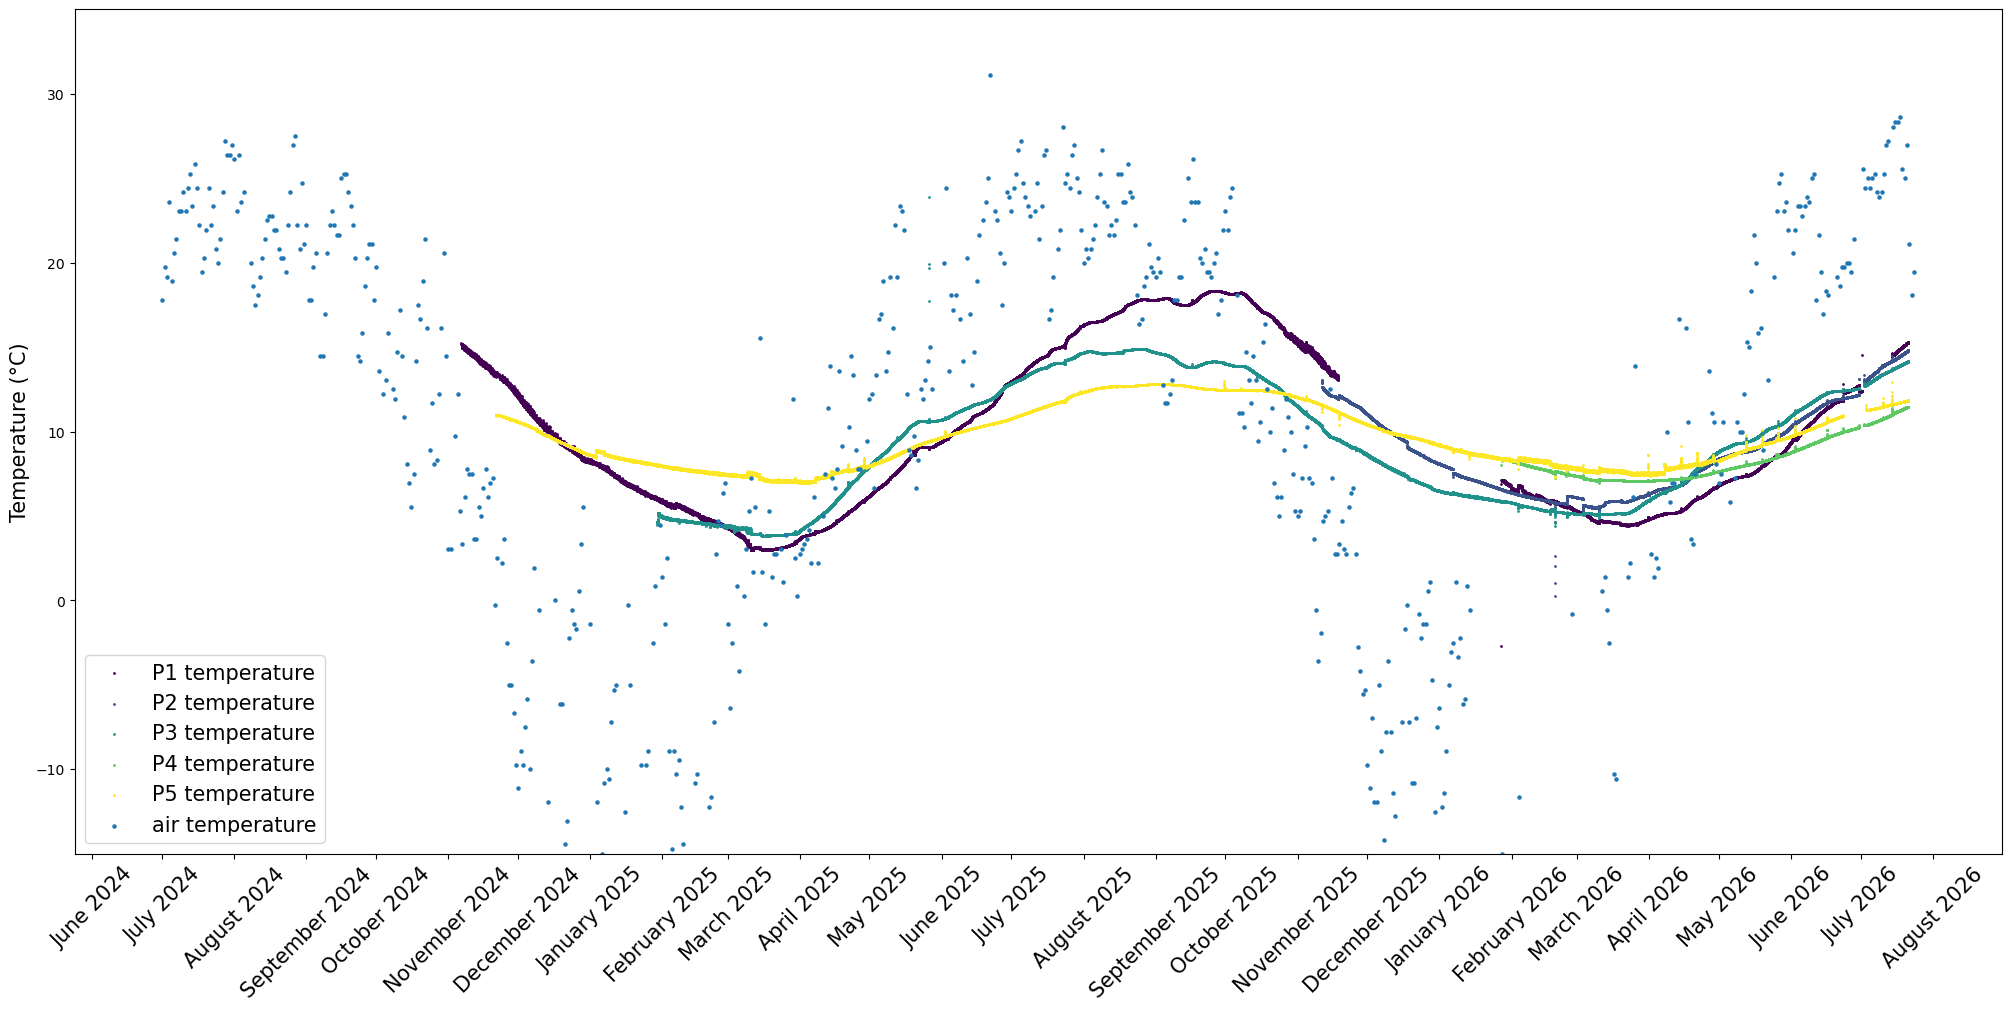

In [136]:

fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))
ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, s = 1, color = one, label = 'P1 temperature')
ax.scatter(P2hobodf.index, P2hobodf.FilteredTemp, s = 1, color = two, label = 'P2 temperature')
ax.scatter(P3hobodf.index, P3hobodf.FilteredTemp, s = 1, color = three, label = 'P3 temperature')
ax.scatter(P4hobodf.index, P4hobodf.FilteredTemp, s = 1, color = four, label = 'P4 temperature')
ax.scatter(P5hobodf.index, P5hobodf.FilteredTemp, s = 1, color = five, label = 'P5 temperature')

ax.scatter(weatherdf.Date, weatherdf.MeanTempC, s = 5, label = 'air temperature') 

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
plt.xticks(rotation=45, fontsize = 15)

# plt.xlabel('date', fontsize = 15)
plt.ylabel('Temperature (°C)', fontsize = 15)
plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))



#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.legend(loc="lower left", fontsize = 15)
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

# Other plots

Creek temperatures:

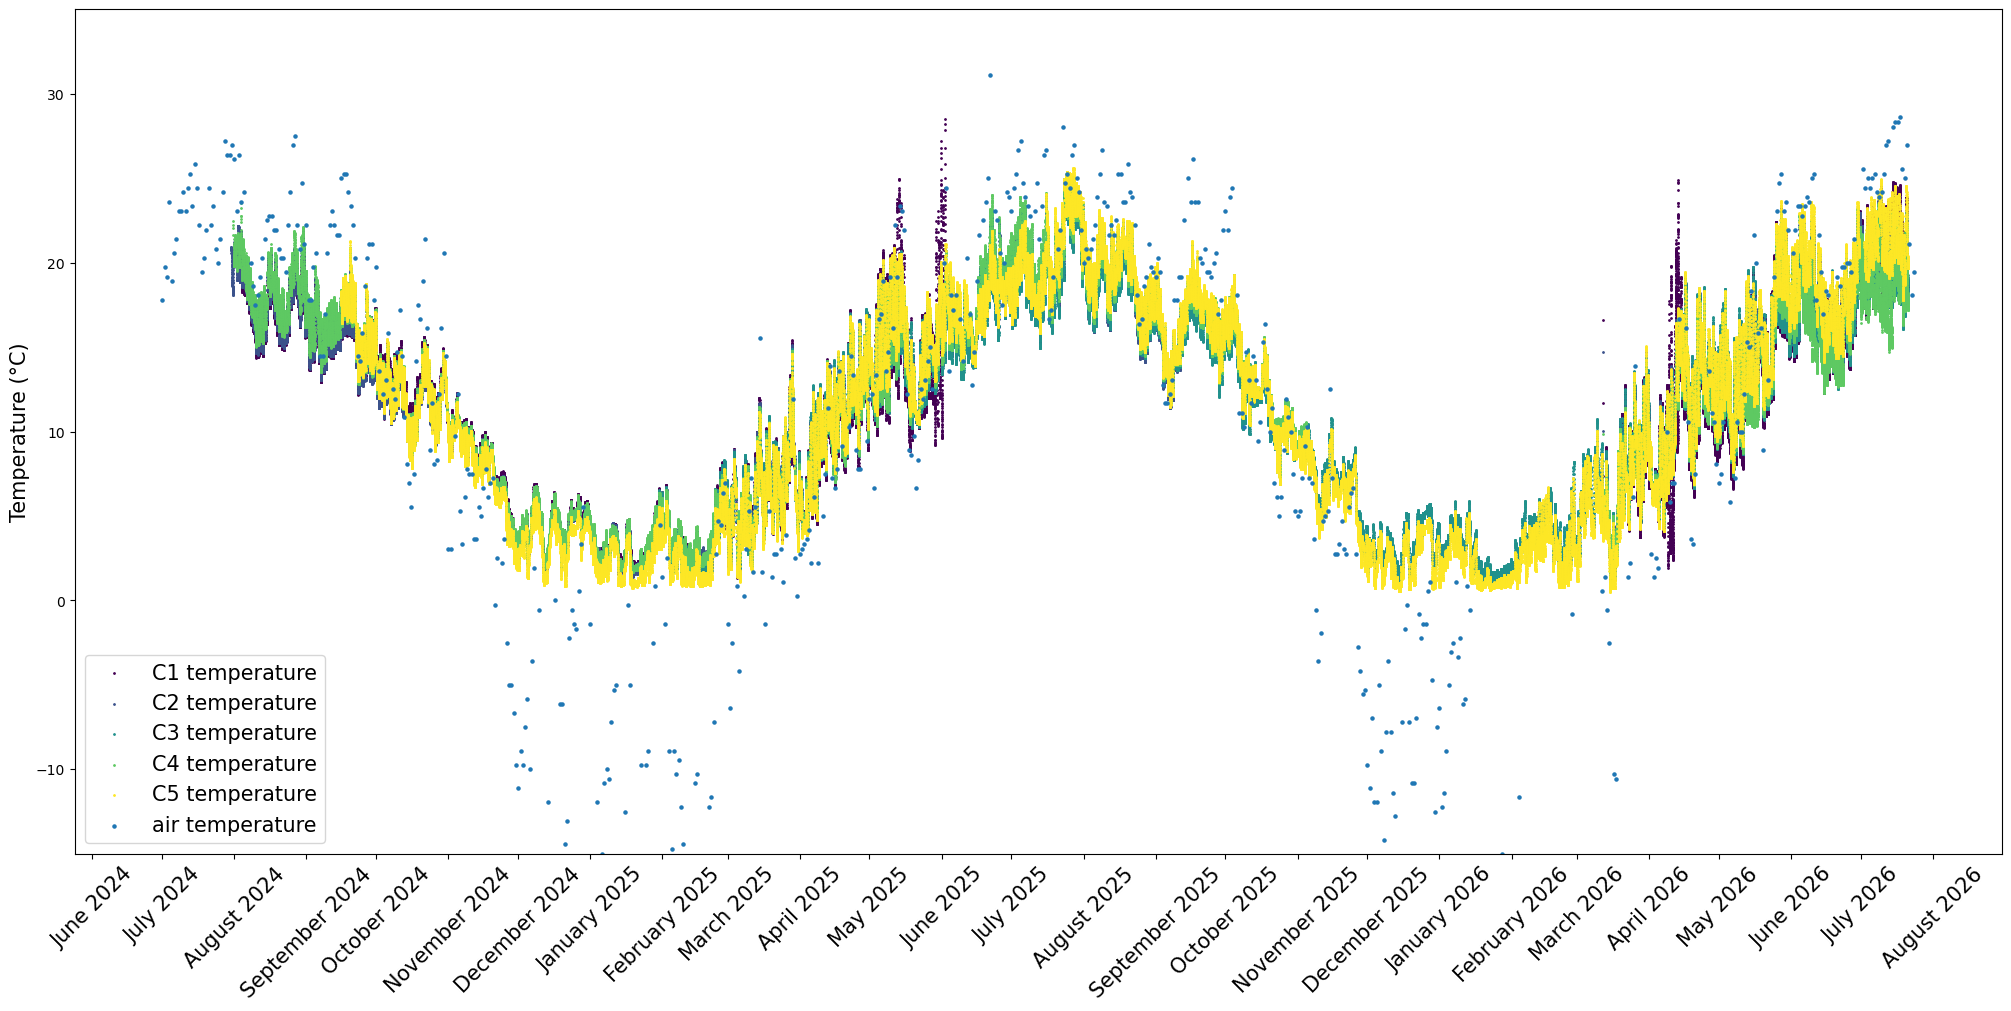

In [138]:
fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, s = 1, color = one, label = 'C1 temperature')
ax.scatter(C2hobodf.index, C2hobodf.FilteredTemp, s = 1, color = two, label = 'C2 temperature')
ax.scatter(midst.index, midst.FilteredTemp, s = 1, color = three, label = 'C3 temperature')
ax.scatter(C4hobodf.index, C4hobodf.FilteredTemp, s = 1, color = four, label = 'C4 temperature')
ax.scatter(C5hobodf.index, C5hobodf.FilteredTemp, s = 1, color = five, label = 'C5 temperature')

ax.scatter(weatherdf.Date, weatherdf.MeanTempC, s = 5, label = 'air temperature') 

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
plt.xticks(rotation=45, fontsize = 15)

# plt.xlabel('date', fontsize = 15)
plt.ylabel('Temperature (°C)', fontsize = 15)
plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))



#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.legend(loc="lower left", fontsize = 15)
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

Cleaning the data further: Because the Hobos take measurements on offset 15-min intervals, it can be helpful to reassign the timestamps to the nearest 15 minutes. 

In [140]:
# Resample the piezometer data.
P1hobodf.set_index('Date-Time', inplace=True)
P1hobodf.index = P1hobodf.index.round('15min')

In [141]:
# Resample the stream data.
downst.set_index('Date-Time', inplace=True)
downst.index = downst.index.round('15min')

The Hobos are set to adjust for daylight savings time, so once a year, on November 2, they each record 1-2 am twice. On March 9, they miss the hour completely.

In [142]:
# Run df.index.is_unique to see if the dataframe has daylight savings duplicates. 
P1hobodf.index.is_unique

False

In [143]:
# If is_unique returns 'False', print the duplicate rows to check that it is the daylight savings day and not a different error.
duplicate_rows = P1hobodf.loc[P1hobodf.index.duplicated()]
print(duplicate_rows)


                     Temperature  Electrical Conductivity  \
Date-Time                                                   
2025-11-02 01:00:00        14.99                    674.1   
2025-11-02 01:15:00        15.19                    676.3   
2025-11-02 01:30:00        15.26                    676.5   
2025-11-02 01:45:00        15.10                    673.2   

                     Specific Conductivity  Salinity  Total Dissolved Solids  \
Date-Time                                                                      
2025-11-02 01:00:00                  853.5      0.41                  438.18   
2025-11-02 01:15:00                  851.7      0.41                  439.59   
2025-11-02 01:30:00                  850.6      0.41                  439.74   
2025-11-02 01:45:00                  849.9      0.41                  437.58   

                     FilteredTemp  FilteredSPC  
Date-Time                                       
2025-11-02 01:00:00         14.99   853.500000  
2025-

In [144]:
# For ease, I just delete the four rows that correspond to the second 1 am hour on November 2. 
P1hobodf = P1hobodf.loc[~P1hobodf.index.duplicated(keep='first')]

In [145]:
# Check the creek data for the same error. If it exists, run .index.duplicated(keep='first') to remove it.
downst = downst.loc[~downst.index.duplicated(keep='first')]

# Plotting the creek and piezometer against each other:

To plot the creek and piezometer against each other, you have to line up the two dataframes by their indeces. This will clip the larger data set to the smaller one. 

In [146]:
# Reindex the piezometer (larger df) to line up with the creek. This makes the two dataframes line up row by row with the same datetime stamps.
P1hobodf = P1hobodf.reindex_like(downst, method = None)

In [147]:
# run df.head() for each df and print their shapes to double check that you reindexed correctly.
print('downst shape:', downst.FilteredSPC.shape, 'Total size:', downst.FilteredSPC.size)
print('piezo shape:', P1hobodf.FilteredSPC.shape, 'Total size:', P1hobodf.FilteredSPC.size)

downst shape: (51473,) Total size: 51473
piezo shape: (51473,) Total size: 51473


In [148]:
# Create a column 'mos' in P1hobodf that is the spring form of the month and year from each measurement
P1hobodf['mos'] = P1hobodf.index.to_period('M')
P1hobodf['mos'] = P1hobodf.mos.dt.strftime('%B %Y')

In [149]:
# Create a column 'mos' in downst that is the spring form of the month and year from each measurement
downst['mos'] = downst.index.to_period('M')
downst['mos'] = downst.mos.dt.strftime('%B %Y')

Create a dictionary to color-code the data by month.

In [150]:
# Create a variable that is a list of all of the months during which data was collected (from the column 'mos'). 
month = downst.mos.unique()

In [151]:
print(month)

<StringArray>
[  'January 2025',  'February 2025',     'March 2025',     'April 2025',
       'May 2025',      'June 2025',      'July 2025',    'August 2025',
 'September 2025',   'October 2025',  'November 2025',  'December 2025',
   'January 2026',  'February 2026',     'March 2026',     'April 2026',
       'May 2026',      'June 2026',      'July 2026']
Length: 19, dtype: str


In [152]:
# Create a dictionary assigning each a color. This is a perceptually uniform list of rainbow-order colors.
# Earlier dates are reds, later is purples. 
colors = {'January 2025':'#ff5e00', 'February 2025':'#ffa400', 'March 2025': '#ffea00', 'April 2025':'#cdff00', 'May 2025':'#8dff00', 'June 2025':'#46ff00', 'July 2025':'#00ff00', 'August 2025':'#00ff46', 'September 2025':'#00ff8c', 'October 2025':'#00ffcc', 'November 2025': '#00ecff', 'December 2025':'#00a5ff', 'January 2026':'#005eff', 'February 2026':'#0018ff', 'March 2026':'#2a00ff', 'April 2026':'#7000ff', 'May 2026':'#b700ff', 'June 2026':'#fe00ff', 'July 2026':'#ff00bf'}

Make a new dataframe (here I called it stat1, for station 1) that is the two dataframes merged.

In [153]:
stat1 = pd.merge(downst, P1hobodf, on = 'Date-Time')

Plot the stream conductivity against the piezometer conductivity. This helps look at relationships between the two.

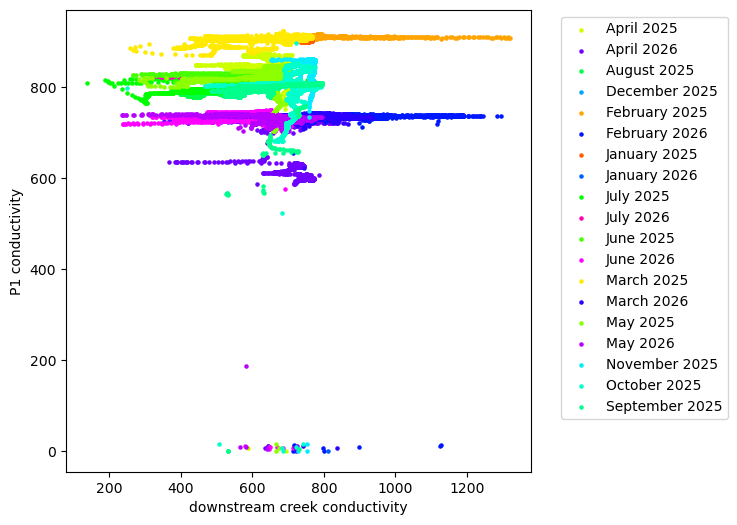

In [156]:
# Source - https://stackoverflow.com/a/26139658
# Posted by Ffisegydd, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-29, License - CC BY-SA 4.0

fig, ax = plt.subplots(figsize=(6, 6))

grouped = stat1.groupby('mos_x')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='Specific Conductivity_x', y='Specific Conductivity_y', s = 5, label=key, color=colors[key])

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('P1 conductivity')
plt.xlabel('downstream creek conductivity')
plt.show()